In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
pd.DataFrame({
    "DType": df.dtypes,
    "null_ratio": df.isnull().sum(),
    "nunique": df.nunique()
})

,DType,null_ratio,nunique
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['Partner'] = le.fit_transform(df['Partner'])
df['Dependents'] = le.fit_transform(df['Dependents'])
df['PhoneService'] = le.fit_transform(df['PhoneService'])
df['MultipleLines'] = le.fit_transform(df['MultipleLines'])
df['InternetService'] = le.fit_transform(df['InternetService'])
df['OnlineSecurity'] = le.fit_transform(df['OnlineSecurity'])
df['OnlineBackup'] = le.fit_transform(df['OnlineBackup'])
df['DeviceProtection'] = le.fit_transform(df['DeviceProtection'])
df['TechSupport'] = le.fit_transform(df['TechSupport'])
df['StreamingTV'] = le.fit_transform(df['StreamingTV'])
df['StreamingMovies'] = le.fit_transform(df['StreamingMovies'])
df['Contract'] = le.fit_transform(df['Contract'])
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])
df['PaymentMethod'] = le.fit_transform(df['PaymentMethod'])
df['Churn'] = le.fit_transform(df['Churn'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


Churn rates and retention trends

In [7]:
# Overall churn rate
churn_rate = df['Churn'].mean() * 100
retention_rate = 100 - churn_rate

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Overall Retention Rate: {retention_rate:.2f}%")

Churn Rate: 26.54%
Overall Retention Rate: 73.46%


In [8]:
retention_trend = 1 - df.groupby('tenure')['Churn'].mean()

In [11]:
churn_contract = df.groupby('Contract')['Churn'].mean() * 100
print("\nChurn Rate by Contract Type:\n", churn_contract)



Churn Rate by Contract Type:
 Contract
0    42.709677
1    11.269518
2     2.831858
Name: Churn, dtype: float64


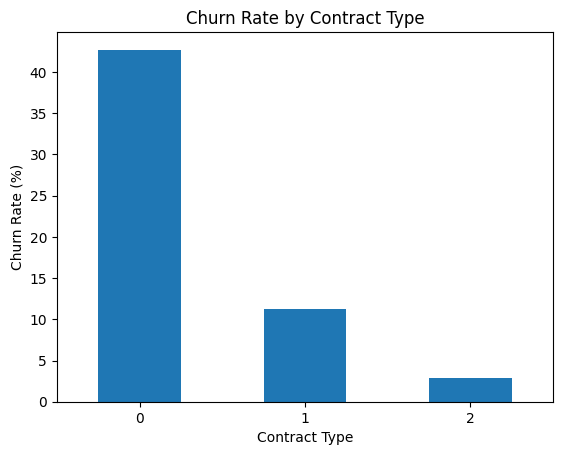

In [20]:
# Churn by Contract
plt.figure()
churn_contract.plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)
plt.show()

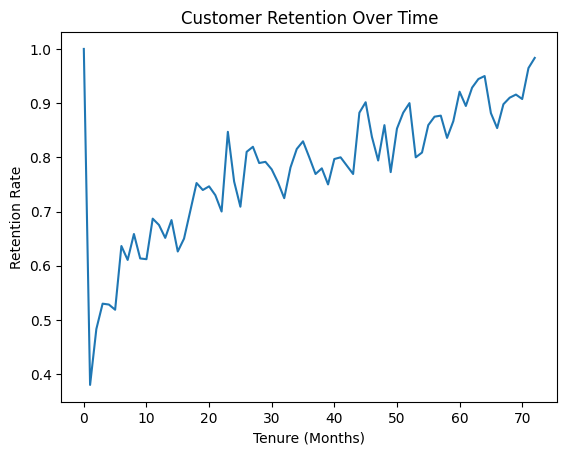

In [21]:
# Retention Trend Over Time
plt.figure()
retention_trend.plot()
plt.title("Customer Retention Over Time")
plt.ylabel("Retention Rate")
plt.xlabel("Tenure (Months)")
plt.show()

Customer cohorts (by signup month, plan, or region)

In [24]:
df['cohort_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])


In [25]:
cohort_tenure = df.groupby('cohort_group')['Churn'].agg(['count', 'sum'])
cohort_tenure['churn_rate'] = (cohort_tenure['sum'] / cohort_tenure['count']) * 100

print("\nCohort by Tenure:\n", cohort_tenure)


Cohort by Tenure:
               count   sum  churn_rate
cohort_group                         
0-1yr          2175  1037   47.678161
1-2yr          1024   294   28.710938
2-4yr          1594   325   20.388959
4-6yr          2239   213    9.513176


In [26]:
# Cohort by Plan (Contract)
cohort_plan = df.groupby('Contract')['Churn'].agg(['count', 'sum'])
cohort_plan['churn_rate'] = (cohort_plan['sum'] / cohort_plan['count']) * 100

print("\nCohort by Plan:\n", cohort_plan)


Cohort by Plan:
           count   sum  churn_rate
Contract                         
0          3875  1655   42.709677
1          1473   166   11.269518
2          1695    48    2.831858


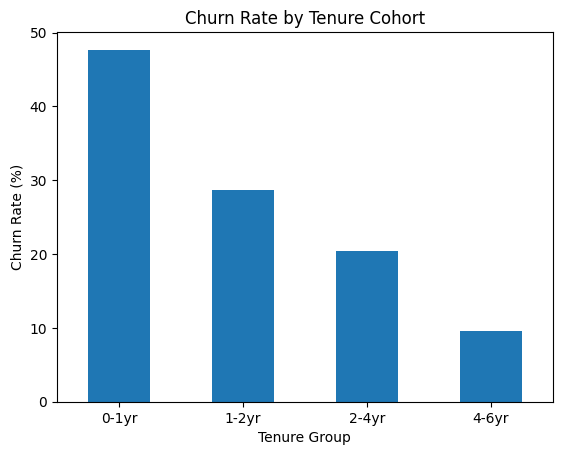

In [28]:
# Tenure Cohort Plot
plt.figure()
cohort_tenure['churn_rate'].plot(kind='bar')
plt.title("Churn Rate by Tenure Cohort")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

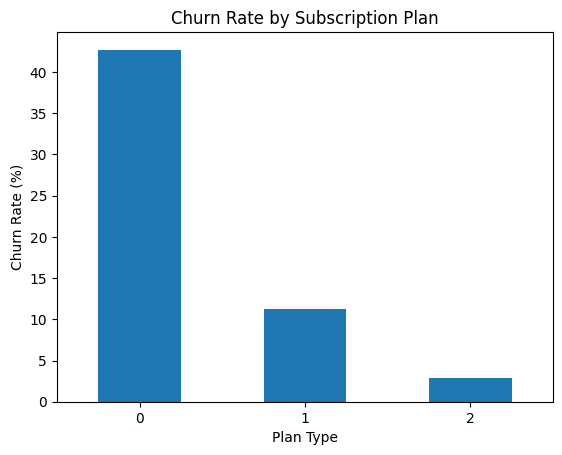

In [30]:
# Plan Cohort Plot
plt.figure()
cohort_plan['churn_rate'].plot(kind='bar')
plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Customer lifetime patterns


Average Tenure:
 Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

Average CLV:
 Churn
0    2549.770883
1    1531.608828
Name: CLV, dtype: float64

Average Monthly Charges:
 Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

Churn by Tenure Group:
 TenureGroup
0-1yr    47.678161
1-2yr    28.710938
2-4yr    20.388959
4-6yr     9.513176
Name: Churn, dtype: float64


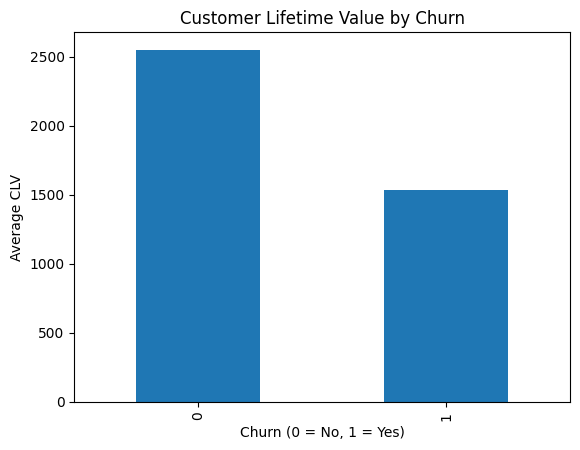

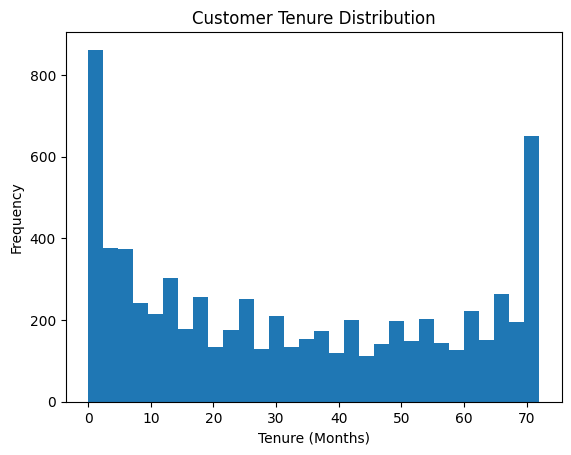

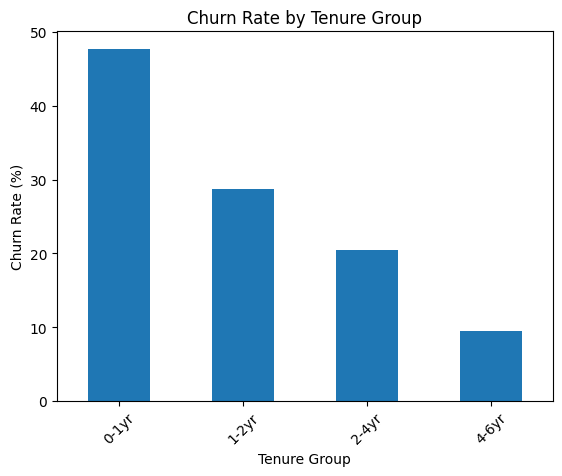

In [31]:
# Create Lifetime Metrics

# Customer Lifetime Value (CLV)
df['CLV'] = df['MonthlyCharges'] * df['tenure']

# Average Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Tenure Groups
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])


# Lifetime Analysis

# Average tenure by churn
tenure_analysis = df.groupby('Churn')['tenure'].mean()
print("\nAverage Tenure:\n", tenure_analysis)

# CLV by churn
clv_analysis = df.groupby('Churn')['CLV'].mean()
print("\nAverage CLV:\n", clv_analysis)

# Monthly charges by churn
monthly_analysis = df.groupby('Churn')['MonthlyCharges'].mean()
print("\nAverage Monthly Charges:\n", monthly_analysis)

# Tenure group churn
tenure_group_analysis = df.groupby('TenureGroup')['Churn'].mean() * 100
print("\nChurn by Tenure Group:\n", tenure_group_analysis)



# CLV by churn
plt.figure()
df.groupby('Churn')['CLV'].mean().plot(kind='bar')
plt.title("Customer Lifetime Value by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average CLV")
plt.show()

# Tenure distribution
plt.figure()
df['tenure'].plot(kind='hist', bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()

# Churn by tenure group
plt.figure()
tenure_group_analysis.plot(kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Churn Rate by Feature

def churn_analysis(column):
    result = df.groupby(column)['Churn'].mean() * 100
    print(f"\nChurn Rate by {column}:\n", result.sort_values(ascending=False))

# Analyze key features
features = [
    'Contract',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'PaymentMethod',
    'PaperlessBilling'
]

for col in features:
    churn_analysis(col)

# Numerical Feature Analysis

print("\nAverage Values by Churn:\n")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean())

# Correlation with Churn
# Convert categorical variables to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)

print("\nTop Positive Correlation (Churn Drivers):\n", correlation.head(10))
print("\nTop Negative Correlation (Retention Drivers):\n", correlation.tail(10))


Churn Rate by Contract:
 Contract
0    42.709677
1    11.269518
2     2.831858
Name: Churn, dtype: float64

Churn Rate by InternetService:
 InternetService
1    41.892765
0    18.959108
2     7.404980
Name: Churn, dtype: float64

Churn Rate by TechSupport:
 TechSupport
0    41.635474
2    15.166341
1     7.404980
Name: Churn, dtype: float64

Churn Rate by OnlineSecurity:
 OnlineSecurity
0    41.766724
2    14.611194
1     7.404980
Name: Churn, dtype: float64

Churn Rate by PaymentMethod:
 PaymentMethod
2    45.285412
3    19.106700
0    16.709845
1    15.243101
Name: Churn, dtype: float64

Churn Rate by PaperlessBilling:
 PaperlessBilling
1    33.565092
0    16.330084
Name: Churn, dtype: float64

Average Values by Churn:

          tenure  MonthlyCharges  TotalCharges
Churn                                         
0      37.569965       61.265124   2552.882494
1      17.979133       74.441332   1531.796094
